# STEP 15. 주변 여건 통제변수: 인구·소득·일자리·토지이용·용도지역·지하철·공원 공급

**목적**: 상업 활동 회귀에서 공원 네트워크와 무관한 입지 조건을 통제할 변수를 만든다. 연구 개요의 통제변수(ACS 인구·사회경제, LODES 일자리, 토지이용 강도)에 용도지역·지하철·공원 공급을 더한다.

| 통제변수 | 자료 | 기준 |
|---|---|---|
| 인구 | ACS 5년 블록그룹 인구(B01003)를 2020 Census 블록 인구 비율로 블록에 나눔 | ACS 2020–2024, Census 2020 |
| 소득·학력 | ACS 5년 트랙트 중위 가구소득(B19013), 25세 이상 학사 이상 비율(B15003) | ACS 2020–2024 |
| 일자리 | LODES WAC 블록: 전체(C000), 소매(CNS07), 숙박·음식(CNS18) | 2023 (최신) |
| 토지이용 강도 | PLUTO 필지: 연면적, 상업·소매·사무 연면적, 주거 세대 수 | 26v2 |
| 용도지역 | DCP 용도지역(nyzd), 상업 오버레이(nyco) | 2026-08 |
| 지하철 | MTA 역, 출입구 | 2024–2026 |
| 공원 공급 | NYC Parks 전체 폴리곤 | 2026-09 |

**집계 범위**
- **상업 영역**(STEP 13): `rule` = `nearest`(주) / `overlap`(민감도) / `buffer`(직선 버퍼, 비교).
  - 블록 자료와 용도지역은 영역 폴리곤과 겹치는 **면적 비율**로 배분한다.
  - PLUTO 필지는 POI와 같은 규칙으로 배정한다: 필지 중심점 → 가장 가까운 가로 표본점(50 m 이내) → 그 점의 공원.
- **주변 400 m**(`n400_*`): 구성 공원에서 직선 400 m 이내. 배후 수요를 보는 맥락 변수라 직선 거리로 둔다.

**Census API 키**: 실행할 때 `CensusAPIkey.txt`에서 읽는다. 키는 출력하지 않고 저장 파일에도 남기지 않는다. 받은 표는 `Data/external/`에 저장해 다시 호출하지 않는다.

**출력**: `outputs/{AREA}/controls/park_context_controls.csv`, `cluster_context_controls.csv`, `context_sources.csv`, `README_context.md`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 직선 100 m 버퍼 (비교용)

# 상업 영역 (주 정의): 공원 가장자리에서 보행망을 따라 100 m 이내의 가로
COMMERCIAL_DIST = 100     # 네트워크 거리 한계 (m)
FRONT_DEPTH = 50          # POI·필지를 가로에 붙이는 최대 거리 겸 영역 폴리곤 깊이 (m)
REACH_STEP = 2.5          # 가로 표본 간격 (m)
FRONT_KINDS = ["street"]  # 상점이 접하는 가로로 보는 세그먼트 종류

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import re
import requests
import shapely
from pyproj import Transformer
from scipy.spatial import cKDTree

EXT = DATA / "external"
EXT.mkdir(exist_ok=True)
CT_DIR = OUT_DIR / "controls"
CT_DIR.mkdir(parents=True, exist_ok=True)
CL_DIR = OUT_DIR / "clusters"
COUNTIES = {"005": "Bronx", "047": "Brooklyn", "061": "Manhattan", "081": "Queens", "085": "Staten Island"}
ACS_YEAR, LODES_YEAR = 2024, 2023
NBHD = 400                        # 주변 맥락 반경 (m, 직선)
PARK_SUPPLY_R = [400, 800]        # 공원 공급을 재는 반경 (m)
SQFT = 0.09290304                 # ft² → m²
DEFS = ["D", "N1", "N2", "N3"]
SOURCES = []

## 15-1. 자료 받기
이미 받은 파일은 다시 받지 않는다.

In [3]:
def fetch(name, url, params=None, timeout=1800):
    f = EXT / name
    if not (f.exists() and f.stat().st_size > 0):
        with requests.get(url, params=params, stream=True, timeout=timeout) as r:
            if r.status_code != 200:
                raise RuntimeError(f"download failed for {name}: HTTP {r.status_code}")
            tmp = f.with_suffix(f.suffix + ".part")
            with open(tmp, "wb") as fh:
                for chunk in r.iter_content(1 << 20):
                    fh.write(chunk)
            tmp.rename(f)
    SOURCES.append({"file": name, "source": url, "size_mb": round(f.stat().st_size / 1e6, 1),
                    "downloaded": time.strftime("%Y-%m-%d", time.localtime(f.stat().st_mtime))})
    return f


def census(dataset, get, for_, in_, name):
    """Census API → 표. 카운티별로 한 번씩 호출하고 Data/external에 저장한다. 키와 요청 주소는 출력하지 않는다."""
    f = EXT / name
    if not f.exists():
        m = re.search(r"[0-9a-fA-F]{40}", (ROOT / "CensusAPIkey.txt").read_text())
        if not m:
            raise RuntimeError("CensusAPIkey.txt에서 40자 키를 찾지 못함")
        frames = []
        for county in COUNTIES:
            try:
                r = requests.get(f"https://api.census.gov/data/{dataset}", timeout=300, allow_redirects=False,
                                 params={"get": get, "for": for_, "in": in_.format(county=county), "key": m.group(0)})
                status, ok = r.status_code, r.status_code == 200 and r.text.lstrip().startswith("[")
                rows = r.json() if ok else None
            except Exception as err:      # 예외 메시지에 요청 주소(키 포함)가 들어가므로 종류만 남긴다
                raise RuntimeError(f"Census API request failed ({dataset}, county {county}): {type(err).__name__}") from None
            if not ok:
                raise RuntimeError(f"Census API error ({dataset}, county {county}): HTTP {status}")
            frames.append(pd.DataFrame(rows[1:], columns=rows[0]))
        pd.concat(frames, ignore_index=True).to_csv(f, index=False)
    SOURCES.append({"file": name, "source": f"https://api.census.gov/data/{dataset} ({get}; {for_})", "size_mb": round(f.stat().st_size / 1e6, 1),
                    "downloaded": time.strftime("%Y-%m-%d", time.localtime(f.stat().st_mtime))})
    return pd.read_csv(f, dtype=str)


F_BLOCKS = fetch("nyc_blocks_2020.zip", "https://data.cityofnewyork.us/api/geospatial/wmsu-5muw", {"method": "export", "format": "Shapefile"})
F_TRACTS = fetch("nyc_tracts_2020.geojson", "https://data.cityofnewyork.us/resource/63ge-mke6.geojson", {"$limit": 5000})
F_LODES = fetch(f"lodes_ny_wac_{LODES_YEAR}.csv.gz", f"https://lehd.ces.census.gov/data/lodes/LODES8/ny/wac/ny_wac_S000_JT00_{LODES_YEAR}.csv.gz")
F_ZONING = fetch("nyc_zoning_202608.zip", "https://s-media.nyc.gov/agencies/dcp/assets/files/zip/data-tools/bytes/gis-zoning-features/nycgiszoningfeatures_202608shp.zip")
F_STATIONS = fetch("mta_subway_stations.csv", "https://data.ny.gov/resource/39hk-dx4f.csv", {"$limit": 5000})
F_ENTRANCES = fetch("mta_subway_entrances.csv", "https://data.ny.gov/resource/i9wp-a4ja.csv", {"$limit": 5000})
PLUTO_COLS = "bbl,borough,landuse,bldgarea,comarea,resarea,retailarea,officearea,unitsres,unitstotal,zonedist1,overlay1,spdist1,xcoord,ycoord,latitude,longitude"
F_PLUTO = fetch("pluto_26v2.csv", "https://data.cityofnewyork.us/resource/64uk-42ks.csv", {"$select": PLUTO_COLS, "$order": "bbl", "$limit": 1000000})
C_BLOCK = census("2020/dec/pl", "P1_001N,H1_001N", "block:*", "state:36 county:{county} tract:*", "census2020_blocks.csv")
C_BG = census(f"{ACS_YEAR}/acs/acs5", "B01003_001E", "block group:*", "state:36 county:{county} tract:*", f"acs{ACS_YEAR}_blockgroups.csv")
C_TRACT = census(f"{ACS_YEAR}/acs/acs5", "B19013_001E,B01003_001E,B15003_001E,B15003_022E,B15003_023E,B15003_024E,B15003_025E",
                 "tract:*", "state:36 county:{county}", f"acs{ACS_YEAR}_tracts.csv")
print(f"blocks {len(C_BLOCK):,}, block groups {len(C_BG):,}, tracts {len(C_TRACT):,}")
pd.DataFrame(SOURCES)

blocks 37,984, block groups 6,807, tracts 2,327


,file,source,size_mb,downloaded
0,nyc_blocks_2020.zip,https://data.cityofnewyork.us/api/geospatial/w...,7.2,2026-10-01
1,nyc_tracts_2020.geojson,https://data.cityofnewyork.us/resource/63ge-mk...,7.8,2026-10-01
2,lodes_ny_wac_2023.csv.gz,https://lehd.ces.census.gov/data/lodes/LODES8/...,2.8,2026-10-01
3,nyc_zoning_202608.zip,https://s-media.nyc.gov/agencies/dcp/assets/fi...,5.2,2026-10-01
4,mta_subway_stations.csv,https://data.ny.gov/resource/39hk-dx4f.csv,0.1,2026-10-01
5,mta_subway_entrances.csv,https://data.ny.gov/resource/i9wp-a4ja.csv,0.3,2026-10-01
6,pluto_26v2.csv,https://data.cityofnewyork.us/resource/64uk-42...,102.5,2026-10-01
7,census2020_blocks.csv,https://api.census.gov/data/2020/dec/pl (P1_00...,1.0,2026-10-01
8,acs2024_blockgroups.csv,https://api.census.gov/data/2024/acs/acs5 (B01...,0.1,2026-10-01
9,acs2024_tracts.csv,https://api.census.gov/data/2024/acs/acs5 (B19...,0.1,2026-10-01


## 15-2. 블록 표: 인구·주택·일자리·소득·학력
모든 값을 블록 단위의 **더할 수 있는 양**으로 만든다. 그러면 어떤 영역이든 면적 비율로 배분해 합산할 수 있다.
- 인구(ACS) = 블록그룹 인구 × (블록의 2020 인구 ÷ 블록그룹의 2020 인구). 2020 인구가 0인 블록그룹은 면적 비율로 나눈다.
- 소득·학력은 트랙트 값이라, 블록 인구를 가중치로 한 분자·분모를 만든다(영역 값 = Σ분자 ÷ Σ분모).
  - 소득이 계산되지 않은 트랙트(-666666666)는 가중치에서 뺀다. 상한(250,001달러 이상) 트랙트의 인구 비율은 따로 기록한다.

In [4]:
blk = gpd.read_file(F_BLOCKS)[["geoid", "geometry"]].to_crs(CRS)
blk["geometry"] = blk.geometry.make_valid()
blk["area"] = blk.area
cb = C_BLOCK.assign(geoid=C_BLOCK.state + C_BLOCK.county + C_BLOCK.tract + C_BLOCK.block).set_index("geoid")
blk["pop2020"] = pd.to_numeric(cb.P1_001N).reindex(blk.geoid).fillna(0).values
blk["housing_units"] = pd.to_numeric(cb.H1_001N).reindex(blk.geoid).fillna(0).values
blk["bg"], blk["tract"] = blk.geoid.str[:12], blk.geoid.str[:11]
bg = pd.to_numeric(C_BG.assign(g=C_BG.state + C_BG.county + C_BG.tract + C_BG["block group"]).set_index("g").B01003_001E)
bg_pop20 = blk.groupby("bg").pop2020.transform("sum")
bg_area = blk.groupby("bg").area.transform("sum")
w_in_bg = np.where(bg_pop20 > 0, blk.pop2020 / bg_pop20.replace(0, np.nan), blk.area / bg_area)
blk["pop"] = bg.reindex(blk.bg).fillna(0).values * w_in_bg
tr = C_TRACT.assign(g=C_TRACT.state + C_TRACT.county + C_TRACT.tract).set_index("g").apply(pd.to_numeric, errors="coerce")
tr["income"] = tr.B19013_001E.where(tr.B19013_001E > 0)
tr["ba_share"] = (tr[["B15003_022E", "B15003_023E", "B15003_024E", "B15003_025E"]].sum(axis=1) / tr.B15003_001E).where(tr.B15003_001E > 0)
inc, ba = tr.income.reindex(blk.tract).values, tr.ba_share.reindex(blk.tract).values
blk["inc_w"] = np.where(np.isfinite(inc), blk["pop"], 0)
blk["inc_num"] = np.where(np.isfinite(inc), blk["pop"] * np.nan_to_num(inc), 0)
blk["inc_top_w"] = np.where(inc >= 250001, blk["pop"], 0)
blk["ba_w"] = np.where(np.isfinite(ba), blk["pop"], 0)
blk["ba_num"] = np.where(np.isfinite(ba), blk["pop"] * np.nan_to_num(ba), 0)
lod = pd.read_csv(F_LODES, dtype={"w_geocode": str}, usecols=["w_geocode", "C000", "CNS07", "CNS18"])
lod = lod[lod.w_geocode.str[2:5].isin(COUNTIES)].set_index("w_geocode")
for c, n in [("C000", "jobs"), ("CNS07", "jobs_retail"), ("CNS18", "jobs_food")]:
    blk[n] = lod[c].reindex(blk.geoid).fillna(0).values
ADD = ["pop", "pop2020", "housing_units", "jobs", "jobs_retail", "jobs_food", "inc_w", "inc_num", "inc_top_w", "ba_w", "ba_num"]
BLK_G, BLK_A, BLK_X = blk.geometry.values, blk.area.values, blk[ADD].values
chk = pd.DataFrame({
    "source total": [pd.to_numeric(C_BLOCK.P1_001N).sum(), pd.to_numeric(C_BG.B01003_001E).sum(), lod.C000.sum()],
    "in block table": [blk.pop2020.sum(), blk["pop"].sum(), blk.jobs.sum()]},
    index=["population 2020 (Census)", f"population ACS {ACS_YEAR - 4}–{ACS_YEAR}", f"jobs LODES {LODES_YEAR}"])
chk["share kept"] = (chk["in block table"] / chk["source total"]).round(5)
assert (chk["share kept"] > 0.995).all(), "블록 경계와 맞지 않는 값이 0.5%를 넘으면 안 됨"
print(f"{len(blk):,} blocks; tracts with no income estimate: {tr.income.isna().sum()}, top-coded: {(tr.B19013_001E >= 250001).sum()}")
chk.round(0)

37,588 blocks; tracts with no income estimate: 128, top-coded: 13


,source total,in block table,share kept
population 2020 (Census),8804190,8804137.0,1.0
population ACS 2020–2024,8483844,8483844.0,1.0
jobs LODES 2023,4585129,4581241.0,1.0


## 15-3. 용도지역, PLUTO 필지, 지하철, 공원
- 용도지역은 첫 글자로 나눈다: C(상업), M(공업), R(주거), PARK. 상업 오버레이(C1·C2)는 주거지역 위에 얹히는 근린상업 허용 구역이다.
- PLUTO 좌표는 EPSG:2263(피트)이라 프로젝트 좌표계로 바꾼다. 면적은 ft² → m².

In [5]:
zd = gpd.read_file(f"zip://{F_ZONING}!nycgiszoningfeatures_202608shp/nyzd.shp").to_crs(CRS)
zd["geometry"] = zd.geometry.make_valid()
zd["cls"] = zd.ZONEDIST.str[0].map({"C": "c", "M": "m", "R": "r", "P": "park"}).fillna("other")
co = gpd.read_file(f"zip://{F_ZONING}!nycgiszoningfeatures_202608shp/nyco.shp").to_crs(CRS)
co["geometry"] = co.geometry.make_valid()
ZCLS = ["c", "m", "r", "park"]

pl = pd.read_csv(F_PLUTO, dtype={"landuse": str}, low_memory=False).dropna(subset=["xcoord", "ycoord"])
px, py = Transformer.from_crs(2263, CRS, always_xy=True).transform(pl.xcoord.values, pl.ycoord.values)
LOT_XY = np.c_[px, py]
LOT = pd.DataFrame({"lots": 1.0, "bldg_area_m2": pl.bldgarea.fillna(0).values * SQFT, "com_area_m2": pl.comarea.fillna(0).values * SQFT,
                    "retail_area_m2": pl.retailarea.fillna(0).values * SQFT, "office_area_m2": pl.officearea.fillna(0).values * SQFT,
                    "res_area_m2": pl.resarea.fillna(0).values * SQFT, "res_units": pl.unitsres.fillna(0).values,
                    "lots_mixed": (pl.landuse == "4").values.astype(float), "lots_commercial": (pl.landuse == "5").values.astype(float)})
LOT_COLS = LOT.columns.tolist()
LOT_X = LOT.values

ent = pd.read_csv(F_ENTRANCES)
ENT = gpd.GeoSeries(gpd.points_from_xy(ent.entrance_longitude, ent.entrance_latitude), crs=4326).to_crs(CRS).values
sta = pd.read_csv(F_STATIONS).groupby("complex_id")[["gtfs_longitude", "gtfs_latitude"]].mean()
STA = gpd.GeoSeries(gpd.points_from_xy(sta.gtfs_longitude, sta.gtfs_latitude), crs=4326).to_crs(CRS).values

ALL_PARKS = gpd.read_file(PARKS_PATH).to_crs(CRS).geometry.make_valid().values
ALL_PARKS_TREE = shapely.STRtree(ALL_PARKS)
in_park = np.zeros(len(LOT_XY), bool)
in_park[np.unique(ALL_PARKS_TREE.query(shapely.points(LOT_XY), predicate="within")[0])] = True
print(f"zoning districts {len(zd):,} ({zd.cls.value_counts().to_dict()}), overlays {len(co):,}; "
      f"PLUTO lots {len(pl):,} ({in_park.sum():,} inside park land, excluded); subway complexes {len(STA)}, entrances {len(ENT):,}")

zoning districts 5,423 ({'r': 2744, 'park': 1253, 'c': 754, 'm': 671, 'other': 1}), overlays 9,627; PLUTO lots 857,347 (5,271 inside park land, excluded); subway complexes 445, entrances 2,120


## 15-4. 집계 단위 불러오기
STEP 13의 공원별 영역(정밀 도형)과 가로 표본점을 쓴다.

In [6]:
memb = pd.read_csv(CL_DIR / "park_cluster_membership.csv").set_index("park_id")
PIDS = memb.index.tolist()
P = len(PIDS)
PIDX = pd.Series(np.arange(P), index=PIDS)
parks = gpd.read_parquet(NET_DIR / "parks.parquet").loc[PIDS]
GEOM = parks.geometry.values
def load_zones(name):
    """공원 순서대로 정렬한 도형 배열. 비어 있는 영역은 빈 폴리곤으로 둔다."""
    g = gpd.read_parquet(AREA_DIR / name).set_index("park_id").geometry.loc[PIDS]
    return np.array([x if x is not None else shapely.Polygon() for x in g.values], dtype=object)


ZONES = {"nearest": load_zones("park_zones.parquet"), "overlap": load_zones("park_zones_overlap.parquet"),
         "buffer": load_zones("park_zones_buffer.parquet")}
cp = pd.read_parquet(AREA_DIR / "commercial_points.parquet")
cm = pd.read_parquet(AREA_DIR / "commercial_membership.parquet")
CP_TREE = cKDTree(cp[["x", "y"]].values)
CP_OWNER = PIDX.reindex(cp.owner.values).fillna(-1).astype(int).values
CL_NO = {}
for d in DEFS:
    ids, no = np.unique(memb[f"{d}_cluster"].values, return_inverse=True)
    CL_NO[d] = (ids, no)
print(f"{P:,} parks; clusters: " + ", ".join(f"{d} {len(CL_NO[d][0]):,}" for d in DEFS))

2,057 parks; clusters: D 1,132, N1 1,219, N2 1,174, N3 1,991


## 15-5. 집계 함수
- `area_sums(polys)`: 블록 값과 용도지역 면적을 폴리곤별로 합산한다(면적 비율 배분).
- 필지: `(단위, 필지)` 쌍 목록을 만들어 합산한다. 중복 허용 규칙과 군집 단위에서는 같은 필지를 한 단위 안에서 한 번만 센다.
- `finish(df)`: 합계에서 밀도·비율·가중 평균을 만든다. 합계는 더할 수 있으므로, 겹치지 않는 영역(`nearest`, `buffer`)의 군집 값은 공원 값을 더해서 구한다.

In [7]:
def area_sums(polys):
    g = shapely.make_valid(np.array([x if x is not None else shapely.Polygon() for x in polys], dtype=object))
    n = len(g)
    out = pd.DataFrame({"area_m2": shapely.area(g)})
    zi, bi = blk.sindex.query(g, predicate="intersects")
    share = shapely.area(shapely.intersection(BLK_G[bi], g[zi])) / BLK_A[bi]
    for k, c in enumerate(ADD):
        out[c] = np.bincount(zi, weights=share * BLK_X[bi, k], minlength=n)
    zi, qi = zd.sindex.query(g, predicate="intersects")
    ia = shapely.area(shapely.intersection(zd.geometry.values[qi], g[zi]))
    for c in ZCLS:
        sel = zd.cls.values[qi] == c
        out[f"zarea_{c}"] = np.bincount(zi[sel], weights=ia[sel], minlength=n)
    zi, qi = co.sindex.query(g, predicate="intersects")
    out["zarea_overlay"] = np.bincount(zi, weights=shapely.area(shapely.intersection(co.geometry.values[qi], g[zi])), minlength=n)
    return out


def lot_sums(unit, lot, n):
    """(단위 번호, 필지 번호) 쌍 → 단위별 합계. 같은 쌍은 한 번만 센다."""
    pr = np.unique(np.c_[unit, lot], axis=0) if len(unit) else np.zeros((0, 2), int)
    return pd.DataFrame({c: np.bincount(pr[:, 0], weights=LOT_X[pr[:, 1], k], minlength=n) for k, c in enumerate(LOT_COLS)})


SUM_COLS = ["area_m2"] + ADD + [f"zarea_{c}" for c in ZCLS] + ["zarea_overlay"] + LOT_COLS


def finish(s, prefix=""):
    """합계 표 → 분석에 쓰는 변수"""
    ha = s.area_m2 / 1e4
    with np.errstate(all="ignore"):
        o = pd.DataFrame({
            "area_ha": ha, "pop": s["pop"], "pop_density": s["pop"] / ha, "pop2020": s.pop2020, "housing_units": s.housing_units,
            "jobs": s.jobs, "jobs_retail": s.jobs_retail, "jobs_food": s.jobs_food, "job_density": s.jobs / ha,
            "median_income": s.inc_num / s.inc_w.where(s.inc_w > 0), "income_topcoded_share": s.inc_top_w / s.inc_w.where(s.inc_w > 0),
            "ba_share": s.ba_num / s.ba_w.where(s.ba_w > 0),
            "zone_c_share": s.zarea_c / s.area_m2, "zone_m_share": s.zarea_m / s.area_m2, "zone_r_share": s.zarea_r / s.area_m2,
            "overlay_share": s.zarea_overlay / s.area_m2,
            "commercial_zoning_share": ((s.zarea_c + s.zarea_overlay) / s.area_m2).clip(upper=1),
            "lots": s.lots, "bldg_area_m2": s.bldg_area_m2, "com_area_m2": s.com_area_m2, "retail_area_m2": s.retail_area_m2,
            "office_area_m2": s.office_area_m2, "res_area_m2": s.res_area_m2, "res_units": s.res_units,
            "com_floor_share": s.com_area_m2 / s.bldg_area_m2.where(s.bldg_area_m2 > 0),
            "floor_area_ratio": s.bldg_area_m2 / s.area_m2.where(s.area_m2 > 0),
            "lots_mixed_share": s.lots_mixed / s.lots.where(s.lots > 0), "lots_commercial_share": s.lots_commercial / s.lots.where(s.lots > 0)})
    o.loc[s.area_m2.values == 0, :] = np.nan
    return o.add_prefix(prefix)


def by_cluster(sums, no, n):
    return sums.groupby(no).sum().reindex(range(n), fill_value=0).reset_index(drop=True)

## 15-6. 공원 단위 집계

In [8]:
t0 = time.time()
# 필지 → 가장 가까운 가로 표본점 (POI와 같은 규칙)
lot_ok = np.where(~in_park)[0]
dd, nn = CP_TREE.query(LOT_XY[lot_ok], k=1, distance_upper_bound=FRONT_DEPTH)
hit = np.isfinite(dd)
lot_hit, lot_pt = lot_ok[hit], nn[hit]
reached = cp.reached.values[lot_pt]
LOT_NEAR = (CP_OWNER[lot_pt[reached]], lot_hit[reached])                            # (공원, 필지): nearest
mo = pd.DataFrame({"pt": lot_pt[reached], "lot": lot_hit[reached]}).merge(
    pd.DataFrame({"pt": cm.point_id.values, "park": PIDX.loc[cm.park_id.values].values}), on="pt")
LOT_OVER = (mo.park.values, mo.lot.values)                                           # (공원, 필지): overlap
lot_pts = shapely.points(LOT_XY[lot_ok])
zi, li = shapely.STRtree(lot_pts).query(ZONES["buffer"], predicate="intersects")
LOT_BUF = (zi, lot_ok[li])                                                           # (공원, 필지): 직선 버퍼
zi, li = shapely.STRtree(lot_pts).query(GEOM, predicate="dwithin", distance=NBHD)
LOT_N400 = (zi, lot_ok[li])                                                          # (공원, 필지): 주변 400 m
LOT_PAIRS = {"nearest": LOT_NEAR, "overlap": LOT_OVER, "buffer": LOT_BUF}
print(f"lots assigned to a reached street point: {reached.sum():,} of {len(lot_ok):,}; within {NBHD} m of a park: {len(np.unique(LOT_N400[1])):,}  ({time.time() - t0:.0f}s)")

PSUM = {}
for rule in ["nearest", "overlap", "buffer"]:
    PSUM[rule] = pd.concat([area_sums(ZONES[rule]), lot_sums(*LOT_PAIRS[rule], P)], axis=1)[SUM_COLS]
    print(f"  park sums [{rule}]  ({time.time() - t0:.0f}s)")
GEOM = np.asarray(GEOM)
NB_G = shapely.buffer(GEOM, NBHD)
PSUM_N400 = pd.concat([area_sums(NB_G), lot_sums(*LOT_N400, P)], axis=1)[SUM_COLS]

# 지하철: 가장 가까운 출입구까지 직선 거리, 400 m 안 역(환승 단지 단위) 수
_, ei = shapely.STRtree(ENT).query_nearest(GEOM, all_matches=False)
SUB_DIST = shapely.distance(GEOM, ENT[ei])
si, sj = shapely.STRtree(STA).query(GEOM, predicate="dwithin", distance=NBHD)
STA_PAIRS = (si, sj)
SUB_N = np.bincount(si, minlength=P)


def parkland(geoms, r):
    """geoms에서 r m 안의 공원 부지 면적(ha). NYC Parks 전체 폴리곤 기준."""
    out = np.zeros(len(geoms))
    for k, b in enumerate(shapely.buffer(geoms, r)):
        h = ALL_PARKS_TREE.query(b, predicate="intersects")
        if len(h):
            out[k] = shapely.union_all(ALL_PARKS[h]).intersection(b).area / 1e4
    return out


PARK_FIX = pd.DataFrame({"subway_dist_m": SUB_DIST, "subway_stations_400m": SUB_N, "park_acres": parks.piece_acres.values})
for r in PARK_SUPPLY_R:
    PARK_FIX[f"parkland_{r}m_ha"] = parkland(GEOM, r)
frames = []
for rule in ["nearest", "overlap", "buffer"]:
    t = pd.concat([finish(PSUM[rule]), finish(PSUM_N400, "n400_"), PARK_FIX], axis=1)
    t.insert(0, "park_id", PIDS)
    t.insert(0, "rule", rule)
    frames.append(t)
PARK_CTX = pd.concat(frames, ignore_index=True)
PARK_CTX.to_csv(CT_DIR / "park_context_controls.csv", index=False)
print(f"park table: {PARK_CTX.shape}  ({time.time() - t0:.0f}s)")
PARK_CTX.groupby("rule")[["area_ha", "pop", "jobs", "jobs_retail", "median_income", "commercial_zoning_share", "retail_area_m2", "floor_area_ratio",
                          "n400_pop", "n400_jobs", "subway_dist_m", "parkland_400m_ha"]].median().round(2)

lots assigned to a reached street point: 98,272 of 852,076; within 400 m of a park: 609,794  (4s)


  park sums [nearest]  (7s)


  park sums [overlap]  (11s)


  park sums [buffer]  (14s)


park table: (6171, 63)  (40s)


,area_ha,pop,jobs,jobs_retail,median_income,commercial_zoning_share,retail_area_m2,floor_area_ratio,n400_pop,n400_jobs,subway_dist_m,parkland_400m_ha
rule,,,,,,,,,,,,
buffer,4.52,684.75,126.66,6.44,78289.83,0.08,836.13,0.89,11533.71,2247.66,388.1,2.69
nearest,3.47,537.22,98.48,5.03,78289.72,0.08,618.59,0.78,11533.71,2247.66,388.1,2.69
overlap,3.96,660.11,124.93,6.90,78613.41,0.09,918.11,0.80,11533.71,2247.66,388.1,2.69


## 15-7. 군집 단위 집계 (정의별)
- `nearest`, `buffer`: 영역이 겹치지 않으므로 구성 공원의 합계를 더한다.
- `overlap`, 주변 400 m: 구성 공원의 영역이 서로 겹치므로 합집합 도형으로 다시 집계한다. 필지는 군집 안에서 한 번만 센다.

In [9]:
t0 = time.time()
frames = []
for d in DEFS:
    ids, no = CL_NO[d]
    n = len(ids)
    order = pd.Series(np.arange(P)).groupby(no).apply(lambda x: x.values).reindex(range(n)).values       # 군집별 공원 위치
    uni = lambda arr: np.array([shapely.union_all(arr[idx]) for idx in order], dtype=object)
    geom_c = uni(GEOM)
    sums = {"nearest": by_cluster(PSUM["nearest"], no, n), "buffer": by_cluster(PSUM["buffer"], no, n),
            "overlap": pd.concat([area_sums(uni(ZONES["overlap"])), lot_sums(no[LOT_OVER[0]], LOT_OVER[1], n)], axis=1)[SUM_COLS]}
    n400 = pd.concat([area_sums(uni(NB_G)), lot_sums(no[LOT_N400[0]], LOT_N400[1], n)], axis=1)[SUM_COLS]
    fix = pd.DataFrame({"subway_dist_m": pd.Series(SUB_DIST).groupby(no).min().values,
                        "subway_stations_400m": np.bincount(np.unique(np.c_[no[STA_PAIRS[0]], STA_PAIRS[1]], axis=0)[:, 0], minlength=n),
                        "park_acres": pd.Series(parks.piece_acres.values).groupby(no).sum().values})
    for r in PARK_SUPPLY_R:
        fix[f"parkland_{r}m_ha"] = parkland(geom_c, r)
    for rule in ["nearest", "overlap", "buffer"]:
        t = pd.concat([finish(sums[rule]), finish(n400, "n400_"), fix], axis=1)
        t.insert(0, "cluster_id", ids)
        t.insert(0, "definition", d)
        t.insert(0, "rule", rule)
        frames.append(t)
    print(f"  {d}: {n:,} clusters  ({time.time() - t0:.0f}s)")
CLUSTER_CTX = pd.concat(frames, ignore_index=True)
CLUSTER_CTX.to_csv(CT_DIR / "cluster_context_controls.csv", index=False)
CLUSTER_CTX[CLUSTER_CTX.rule == "nearest"].groupby("definition")[
    ["area_ha", "pop", "jobs", "jobs_retail", "median_income", "commercial_zoning_share", "retail_area_m2", "n400_pop", "n400_jobs",
     "subway_dist_m", "parkland_400m_ha"]].median().round(2)

  D: 1,132 clusters  (18s)


  N1: 1,219 clusters  (37s)


  N2: 1,174 clusters  (55s)


  N3: 1,991 clusters  (78s)


,area_ha,pop,jobs,jobs_retail,median_income,commercial_zoning_share,retail_area_m2,n400_pop,n400_jobs,subway_dist_m,parkland_400m_ha
definition,,,,,,,,,,,
D,5.02,677.14,142.32,8.68,83607.17,0.07,1090.59,10496.81,2110.45,447.34,2.54
N1,4.71,581.99,121.66,6.44,82064.88,0.07,774.81,10539.50,2108.47,442.47,3.11
N2,4.82,615.44,127.37,7.08,82924.60,0.07,898.74,10544.40,2022.93,450.54,2.86
N3,3.59,554.55,103.64,5.17,78670.05,0.08,671.69,11510.78,2249.40,384.46,2.70


## 15-8. 검증
1. **면적 배분이 값을 보존하는가**: 보로 경계로 집계한 인구·일자리가 블록 표의 보로 합계와 같은지 본다.
2. **겹치지 않는 영역의 합산**: `nearest` 규칙의 군집 값을 합집합 도형으로 직접 집계한 것과, 공원 값을 더한 것이 같은지 표본으로 본다.
3. 결측과 범위.

In [10]:
boro = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough")
bs = area_sums(boro.geometry.values)
blk["boro"] = blk.geoid.str[2:5].map({"005": "X", "047": "B", "061": "M", "081": "Q", "085": "R"})
ref = blk.groupby("boro")[["pop", "jobs"]].sum().reindex(boro.index)
cons = pd.DataFrame({"pop (borough polygon)": bs["pop"].values, "pop (block table)": ref["pop"].values,
                     "jobs (borough polygon)": bs.jobs.values, "jobs (block table)": ref.jobs.values}, index=boro.index)
cons["pop ratio"] = (cons.iloc[:, 0] / cons.iloc[:, 1]).round(4)
cons["jobs ratio"] = (cons.iloc[:, 2] / cons.iloc[:, 3]).round(4)
assert cons[["pop ratio", "jobs ratio"]].sub(1).abs().max().max() < 0.01, "면적 배분이 보로 합계를 1% 안에서 보존해야 함"
display(cons.round(0))

d = "N1"
ids, no = CL_NO[d]
multi = np.where(np.bincount(no) > 1)[0][:60]
direct = area_sums([shapely.union_all(ZONES["nearest"][no == k]) for k in multi])
added = by_cluster(PSUM["nearest"], no, len(ids)).iloc[multi].reset_index(drop=True)
rel = ((direct[["area_m2", "pop", "jobs"]] - added[["area_m2", "pop", "jobs"]]).abs() / added[["area_m2", "pop", "jobs"]].clip(lower=1)).max()
assert (rel < 0.01).all(), "nearest 규칙: 군집 값 = 구성 공원 값의 합"
print(f"nearest rule, {len(multi)} multi-park {d} clusters: union-geometry sums match added park sums (max relative difference {rel.max():.4f})")

near = PARK_CTX[PARK_CTX.rule == "nearest"]
miss = near.drop(columns=["rule", "park_id"]).isna().mean().sort_values(ascending=False)
print("\nshare of parks with a missing value (nearest rule), top 8:")
print(miss.head(8).round(3).to_string())
num = PARK_CTX.select_dtypes("number")
assert (num.min() >= -1e-9).all(), "음수가 없어야 함"
assert PARK_CTX[["zone_c_share", "zone_m_share", "zone_r_share", "overlay_share", "ba_share"]].max().max() <= 1.0001
assert len(PARK_CTX) == 3 * P and CLUSTER_CTX.groupby(["rule", "definition"]).size().eq(CLUSTER_CTX.groupby(["rule", "definition"]).cluster_id.nunique()).all()

,pop (borough polygon),pop (block table),jobs (borough polygon),jobs (block table),pop ratio,jobs ratio
borough,,,,,,
M,1628884.0,1629477.0,2504417.0,2504505.0,1.0,1.0
X,1405000.0,1404779.0,340390.0,340785.0,1.0,1.0
B,2631534.0,2631580.0,879351.0,879372.0,1.0,1.0
Q,2322713.0,2323052.0,728360.0,728370.0,1.0,1.0
R,494956.0,494956.0,128209.0,128209.0,1.0,1.0


nearest rule, 60 multi-park N1 clusters: union-geometry sums match added park sums (max relative difference 0.0000)

share of parks with a missing value (nearest rule), top 8:
com_floor_share            0.058
lots_commercial_share      0.054
lots_mixed_share           0.054
median_income              0.037
income_topcoded_share      0.037
ba_share                   0.032
area_ha                    0.028
commercial_zoning_share    0.028


## 15-9. 통제변수끼리의 상관
강하게 상관된 변수는 회귀에 같이 넣지 않는다. 가로 통제변수(STEP 14)와 합쳐서 본다. `nearest` 규칙, 공원 단위, Spearman 순위 상관이다.

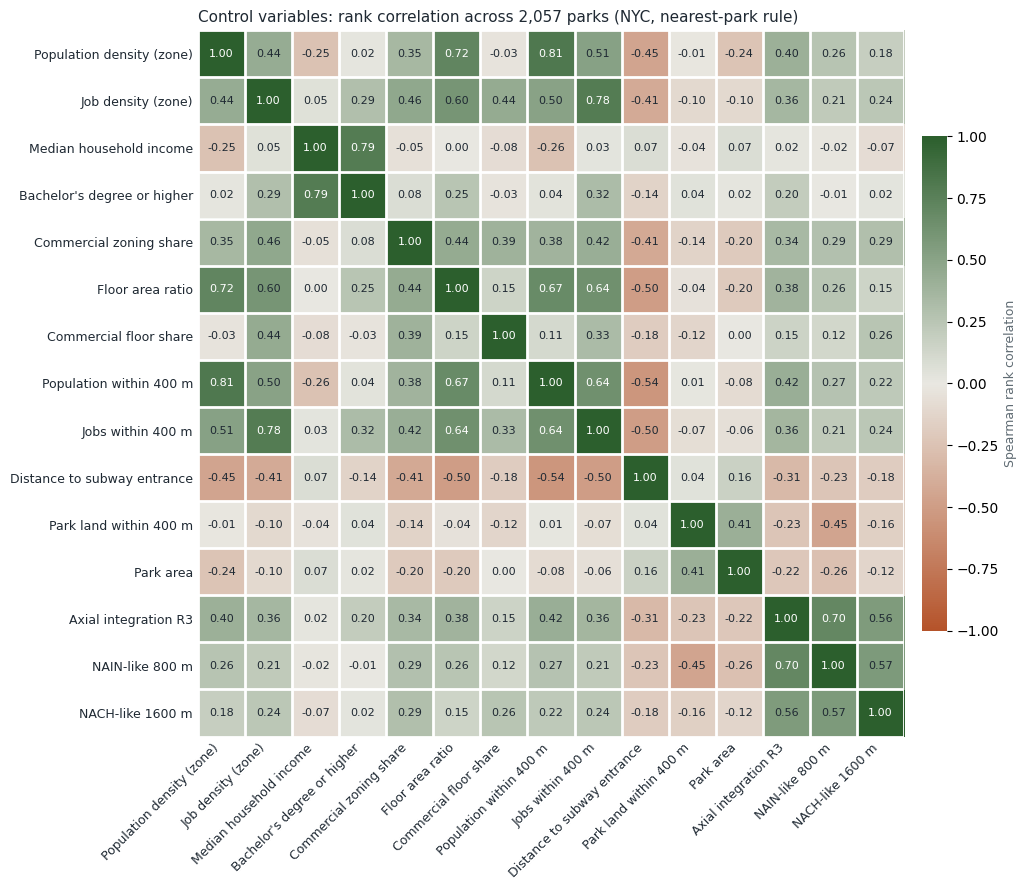

pairs with |rho| ≥ 0.7:
Population density (zone)  Population within 400 m        0.81
Median household income    Bachelor's degree or higher    0.79
Job density (zone)         Jobs within 400 m              0.78
Population density (zone)  Floor area ratio               0.72


In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

street = pd.read_csv(CT_DIR / "park_street_controls.csv")
street = street[street.rule == "nearest"].set_index("park_id")
KEY = {"pop_density": "Population density (zone)", "job_density": "Job density (zone)", "median_income": "Median household income",
       "ba_share": "Bachelor's degree or higher", "commercial_zoning_share": "Commercial zoning share", "floor_area_ratio": "Floor area ratio",
       "com_floor_share": "Commercial floor share", "n400_pop": "Population within 400 m", "n400_jobs": "Jobs within 400 m",
       "subway_dist_m": "Distance to subway entrance", "parkland_400m_ha": "Park land within 400 m", "park_acres": "Park area",
       "ax_int_r3_mean": "Axial integration R3", "nain_800_mean": "NAIN-like 800 m", "nach_1600_mean": "NACH-like 1600 m"}
X = near.set_index("park_id").join(street[["ax_int_r3_mean", "nain_800_mean", "nach_1600_mean"]])[list(KEY)]
CORR = X.corr(method="spearman")
CORR.round(3).to_csv(CT_DIR / "context_correlations.csv")
INK, MUTED_INK = "#1F2933", "#5F6B73"
DIV = LinearSegmentedColormap.from_list("div", ["#B5532A", "#E9E8E2", "#2C5F2D"])     # 음(주황) – 중립 회색 – 양(녹색)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(CORR.values, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR)), [KEY[c] for c in CORR.columns], rotation=45, ha="right", fontsize=9, color=INK)
ax.set_yticks(range(len(CORR)), [KEY[c] for c in CORR.index], fontsize=9, color=INK)
for i in range(len(CORR)):
    for j in range(len(CORR)):
        v = CORR.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else INK)
ax.set_xticks(np.arange(-0.5, len(CORR)), minor=True)
ax.set_yticks(np.arange(-0.5, len(CORR)), minor=True)
ax.grid(which="minor", color="white", lw=2)
ax.tick_params(which="both", length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Spearman rank correlation", color=MUTED_INK, fontsize=9)
cb.outline.set_visible(False)
ax.set_title(f"Control variables: rank correlation across {len(X):,} parks ({STUDY_AREA}, nearest-park rule)", fontsize=11, color=INK, loc="left")
fig.tight_layout()
fig.savefig(CT_DIR / "context_correlations.png", dpi=160, facecolor="white")
plt.show()
hi = CORR.where(np.triu(np.ones(CORR.shape, bool), 1)).stack()
print("pairs with |rho| ≥ 0.7:")
print(hi[hi.abs() >= 0.7].sort_values(ascending=False).round(2).rename(index=KEY).to_string())

## 15-10. 출처 표와 변수 설명

In [12]:
src = pd.DataFrame(SOURCES)
src["vintage"] = src.file.map({
    "nyc_blocks_2020.zip": "2020 census blocks (NYC DCP, clipped to shoreline)", "nyc_tracts_2020.geojson": "2020 census tracts (NYC DCP)",
    f"lodes_ny_wac_{LODES_YEAR}.csv.gz": f"LODES 8.4, {LODES_YEAR}", "nyc_zoning_202608.zip": "NYC DCP zoning features, 2026-08",
    "mta_subway_stations.csv": "MTA Subway Stations", "mta_subway_entrances.csv": "MTA Subway Entrances and Exits: 2024",
    "pluto_26v2.csv": "PLUTO 26v2", "census2020_blocks.csv": "2020 Census PL 94-171",
    f"acs{ACS_YEAR}_blockgroups.csv": f"ACS 5-year {ACS_YEAR - 4}–{ACS_YEAR}", f"acs{ACS_YEAR}_tracts.csv": f"ACS 5-year {ACS_YEAR - 4}–{ACS_YEAR}"})
src.to_csv(CT_DIR / "context_sources.csv", index=False)
readme = f"""# 주변 여건 통제변수 (STEP 15)

공원 네트워크와 무관한 입지 조건을 통제하는 변수다. 가로 구조 통제변수는 `README.md`(STEP 14)를 본다.

## 파일
| 파일 | 단위 | 내용 |
|---|---|---|
| `park_context_controls.csv` | 규칙 × 공원 ({P:,}곳) | 공원별 상업 영역과 주변 {NBHD} m의 값 |
| `cluster_context_controls.csv` | 규칙 × 정의 × 군집 | 군집별 값 |
| `context_sources.csv` | | 자료 출처, 기준, 받은 날짜 |
| `context_correlations.csv` / `.png` | | 통제변수 간 Spearman 상관 (가로 통제변수 포함) |

`rule`: `nearest` = 가장 가까운 공원(네트워크 거리)에 배정한 영역(주 분석), `overlap` = 닿는 모든 공원에 중복 배정(민감도), `buffer` = 직선 {COMMERCIAL_BUFFER} m 버퍼(비교).

## 변수 (상업 영역)
| 변수 | 뜻 |
|---|---|
| `area_ha` | 영역 폴리곤 면적 |
| `pop`, `pop_density` | ACS {ACS_YEAR - 4}–{ACS_YEAR} 인구(블록그룹 값을 2020 블록 인구 비율로 나눔), ha당 인구 |
| `pop2020`, `housing_units` | 2020 Census 블록 인구, 주택 수 |
| `jobs`, `jobs_retail`, `jobs_food`, `job_density` | LODES {LODES_YEAR} 일자리: 전체, 소매, 숙박·음식, ha당 전체 |
| `median_income` | 트랙트 중위 가구소득을 영역 안 인구로 가중 평균 (달러) |
| `income_topcoded_share` | 소득이 상한(250,001달러 이상)인 트랙트에 사는 인구 비율 |
| `ba_share` | 25세 이상 중 학사 이상 비율 (트랙트 값의 인구 가중 평균) |
| `zone_c_share`, `zone_m_share`, `zone_r_share` | 영역 면적 중 상업·공업·주거 용도지역 비율 |
| `overlay_share` | 상업 오버레이(C1·C2) 비율 |
| `commercial_zoning_share` | 상업지역 + 상업 오버레이 비율 |
| `lots` | 영역에 배정된 PLUTO 필지 수 |
| `bldg_area_m2`, `com_area_m2`, `retail_area_m2`, `office_area_m2`, `res_area_m2`, `res_units` | 필지 연면적 합계(전체·상업·소매·사무·주거)와 주거 세대 수 |
| `com_floor_share` | 상업 연면적 ÷ 전체 연면적 |
| `floor_area_ratio` | 전체 연면적 ÷ 영역 면적 (토지이용 강도) |
| `lots_mixed_share`, `lots_commercial_share` | 주상복합(토지이용 4), 상업·사무(토지이용 5) 필지 비율 |

## 변수 (규칙과 무관)
| 변수 | 뜻 |
|---|---|
| `n400_*` | 위와 같은 변수를 구성 공원에서 직선 {NBHD} m 이내로 집계한 값 (배후 수요) |
| `subway_dist_m` | 가장 가까운 지하철 출입구까지 직선 거리 (군집은 구성 공원 중 최솟값) |
| `subway_stations_400m` | 직선 {NBHD} m 안의 역 수 (환승 단지는 하나로 셈) |
| `park_acres` | 공원(군집) 면적 |
| `parkland_400m_ha`, `parkland_800m_ha` | 직선 400 m·800 m 안의 공원 부지 면적. Flagship·대형 공원을 포함한 NYC Parks 전체 기준 |

## 계산 방법
- 블록 자료(인구·주택·일자리)와 용도지역은 영역 폴리곤과 겹치는 면적 비율로 배분한다.
- PLUTO 필지는 POI와 같은 규칙으로 배정한다: 필지 중심점을 가장 가까운 가로 표본점({FRONT_DEPTH} m 이내)에 붙이고, 그 점이 속한 공원에 넣는다. 공원 부지 안의 필지는 뺀다.
- 겹치지 않는 영역(`nearest`, `buffer`)의 군집 값은 구성 공원 값의 합이다. `overlap`과 주변 {NBHD} m는 합집합 도형으로 다시 집계한다.

## 쓸 때 주의
- 일자리는 {LODES_YEAR}년 자료다. Advan {ACS_YEAR}년과 1년 차이가 난다.
- 상업 영역은 가로를 따라가는 좁은 띠라서 영역 안 인구는 적다. 배후 수요는 `n400_pop`, `n400_jobs`가 더 맞다.
- 소득은 트랙트 값이다. 블록그룹보다 오차가 작지만 공간 해상도는 낮다.
- 서로 강하게 상관된 변수는 `context_correlations.csv`에서 확인하고 같이 넣지 않는다.
"""
(CT_DIR / "README_context.md").write_text(readme)
src

,file,source,size_mb,downloaded,vintage
0,nyc_blocks_2020.zip,https://data.cityofnewyork.us/api/geospatial/w...,7.2,2026-10-01,"2020 census blocks (NYC DCP, clipped to shorel..."
1,nyc_tracts_2020.geojson,https://data.cityofnewyork.us/resource/63ge-mk...,7.8,2026-10-01,2020 census tracts (NYC DCP)
2,lodes_ny_wac_2023.csv.gz,https://lehd.ces.census.gov/data/lodes/LODES8/...,2.8,2026-10-01,"LODES 8.4, 2023"
3,nyc_zoning_202608.zip,https://s-media.nyc.gov/agencies/dcp/assets/fi...,5.2,2026-10-01,"NYC DCP zoning features, 2026-08"
4,mta_subway_stations.csv,https://data.ny.gov/resource/39hk-dx4f.csv,0.1,2026-10-01,MTA Subway Stations
5,mta_subway_entrances.csv,https://data.ny.gov/resource/i9wp-a4ja.csv,0.3,2026-10-01,MTA Subway Entrances and Exits: 2024
6,pluto_26v2.csv,https://data.cityofnewyork.us/resource/64uk-42...,102.5,2026-10-01,PLUTO 26v2
7,census2020_blocks.csv,https://api.census.gov/data/2020/dec/pl (P1_00...,1.0,2026-10-01,2020 Census PL 94-171
8,acs2024_blockgroups.csv,https://api.census.gov/data/2024/acs/acs5 (B01...,0.1,2026-10-01,ACS 5-year 2020–2024
9,acs2024_tracts.csv,https://api.census.gov/data/2024/acs/acs5 (B19...,0.1,2026-10-01,ACS 5-year 2020–2024
